### Imports

In [ ]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import cv2
import numpy as np
from pathlib import Path
import math
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.utils import class_weight
from sklearn.preprocessing import LabelEncoder
import tensorflow as tf
from tensorflow.keras.callbacks import ReduceLROnPlateau
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Model

import warnings
warnings.filterwarnings('ignore')

### Load Dataset

In [50]:
landmarks_path= Path("/kaggle/input/final-landmark-dataset/Final Dataset 4 JPG")
classes = os.listdir(landmarks_path)
print(classes)

['The Small Aten Temple', 'Qasr Qarun', 'Pyramid of Meidum', 'Temple of Kom Ombo', 'Temple of Luxor', 'Temple of Isis in Philae', 'Temple of Hathor in Philae', 'Pyramid of Senefru - Bent Pyramid of Senefru', 'Temple of Dakka', 'Temple of Hathor in Dendera', 'Temple of Maharraqa', 'Pyramids of Giza', 'Black Pyramid of Amenemhat III', 'Temple of Horus at Edfu', 'Famine Stele', 'Al Qurn', 'Small Temple of Hathor and Nefertari at Abu Simbel', 'Sphinx', 'Temple of Kalabsha', 'Ptolemaic Temple of Hathor in Deir el Medina', 'Kiosk of Trajan in Philae', 'Temple of Khonsu in Karnak', 'Temple of Karnak', 'Colossoi of Memnon', 'Pyramid of Seila', 'Temple of Hatshepsut in Deir El Bahari', 'Temple of Habu', 'Osireion', 'Ramessum', 'Pyramid of Saqqara - Pyramid of Djoser', 'Temple of Amada', 'Tomb of Horemheb in Saqqara', 'Pyramid of Sahure', 'Sphinx of Memphis', 'Temple of Seti I in Abydos', 'The Roman Mammisi in Dendera', 'Temple of Wadi es-Sebua - Temple of Ramesses II', 'Tomb of Petosiris', 'Tem

In [51]:
len(classes)

52

### Helper Functions

In [52]:
IMG_EXTS = {".jpg", ".jpeg", ".png", ".bmp"}

def list_subdirs(path: Path):
    return sorted([p for p in path.iterdir() if p.is_dir()])

def count_images_recursive(path: Path):
    return sum(1 for p in path.rglob("*") if p.suffix.lower() in IMG_EXTS)

def count_images_in_dir(path: Path):
    return sum(1 for p in path.iterdir() if p.suffix.lower() in IMG_EXTS)

In [53]:
def make_df(landmarks_path: Path):
    rows = []

    for class_dir in list_subdirs(landmarks_path):
        landmark_name = os.path.basename(class_dir)
        for p in class_dir.iterdir():
            if p.suffix.lower() in IMG_EXTS:
                rows.append({"label": str(landmark_name)  , "path": str(p)})

    df = pd.DataFrame(rows, columns=["label", "path"])
    return df

df=make_df(landmarks_path)
df.sample(10)

,label,path
949,Pompeys Pillar - Serapeum of Alexandria,/kaggle/input/final-landmark-dataset/Final Dat...
392,Colossoi of Memnon,/kaggle/input/final-landmark-dataset/Final Dat...
5801,The Great Temple of Ramesses II at Abu Simbel,/kaggle/input/final-landmark-dataset/Final Dat...
1790,Pyramid of Senefru - Bent Pyramid of Senefru,/kaggle/input/final-landmark-dataset/Final Dat...
5251,Temple of Maharraqa,/kaggle/input/final-landmark-dataset/Final Dat...
957,Ptolemaic Temple of Hathor in Deir el Medina,/kaggle/input/final-landmark-dataset/Final Dat...
4308,Temple of Hatshepsut in Deir El Bahari,/kaggle/input/final-landmark-dataset/Final Dat...
3468,Sphinx,/kaggle/input/final-landmark-dataset/Final Dat...
3161,Speos of Horemheb,/kaggle/input/final-landmark-dataset/Final Dat...
2140,Pyramids of Giza,/kaggle/input/final-landmark-dataset/Final Dat...


In [54]:
print("Dataframe shape:", df.shape)

Dataframe shape: (6000, 2)


### EDA

label
Pyramids of Giza                                      814
Temple of Hatshepsut in Deir El Bahari                455
Pyramid of Senefru - Bent Pyramid of Senefru          439
Colossoi of Memnon                                    436
The Great Temple of Ramesses II at Abu Simbel         363
Sphinx                                                337
Pyramid of Saqqara - Pyramid of Djoser                252
Ramessum                                              219
Temple of Horus at Edfu                               192
Kiosk of Trajan in Philae                             171
Temple of Kom Ombo                                    161
Temple of Luxor                                       146
Temple of Isis in Philae                              144
Temple of Hathor in Dendera                           114
Pompeys Pillar - Serapeum of Alexandria               111
Small Temple of Hathor and Nefertari at Abu Simbel     99
Temple of Karnak                                       94
Black Py

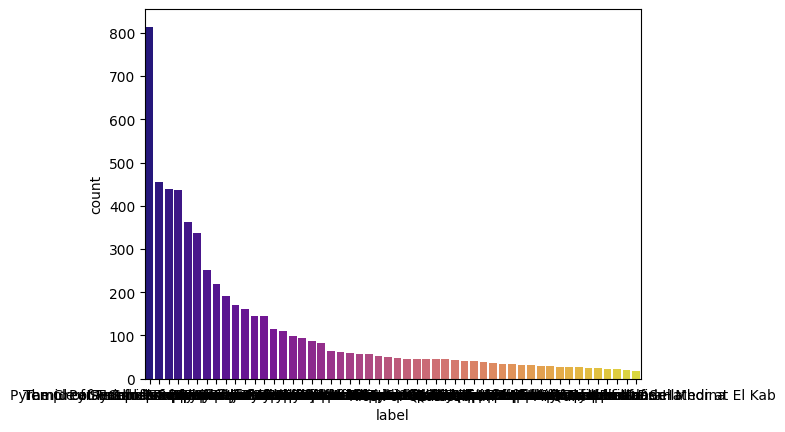

In [55]:
sns.countplot(data=df,x='label',palette='plasma',order=df['label'].value_counts().index )
df['label'].value_counts()

### Data Preprocessing

In [56]:
def show(title, img):
    plt.imshow(img)
    plt.title(title)
    plt.axis("off")
    plt.show()

def load_bgr(path):
    img_bgr = cv2.imread(path)
    if img_bgr is None:
        raise ValueError(f"Could not read {path}")
    return img_bgr

def bgr_to_rgb(img_bgr):
    return cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

In [57]:
image_size = 256
def resize(image, size=image_size):
  return cv2.resize(image,(size,size), interpolation=cv2.INTER_AREA)

#### On-the-fly Augmentation

In [ ]:
train_aug = A.Compose([
    A.HueSaturationValue(hue_shift_limit=10, sat_shift_limit=15, val_shift_limit=10, p=0.2),
    A.HorizontalFlip(p=0.5),
    A.Rotate(limit=15, border_mode=cv2.BORDER_REPLICATE, p=0.5), 
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.5),
    A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.15, rotate_limit=15, border_mode=cv2.BORDER_REPLICATE, p=0.6)
])

def apply_augmentation(image):
    return train_aug(image=image)["image"]

In [59]:
def normalize(image):
  return image/255.0

In [60]:
sample_row = df.iloc[3903]
sample_path = sample_row["path"]
sample_label = sample_row["label"]

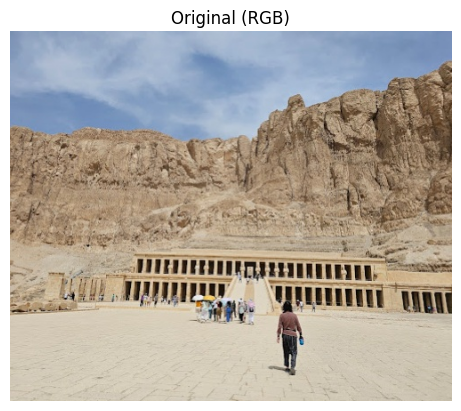

Original shape: (416, 497, 3) dtype: uint8


In [61]:
image_BGR = load_bgr(sample_path)
image_RGB = bgr_to_rgb(image_BGR)

show("Original (RGB)", image_RGB)
print("Original shape:", image_RGB.shape, "dtype:", image_RGB.dtype)

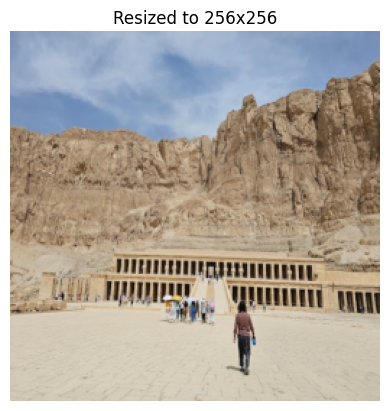

Resized shape: (256, 256, 3)


In [62]:
image_resized= resize(image_RGB,image_size)
show(f"Resized to {image_size}x{image_size}", image_resized)
print("Resized shape:", image_resized.shape)

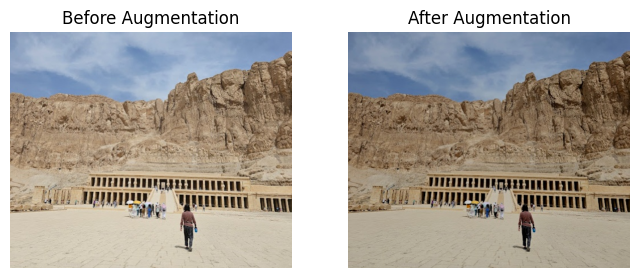

In [63]:
image_augmented = apply_augmentation(image_RGB)

plt.figure(figsize=(8,4))
plt.subplot(1,2,1); plt.imshow(image_RGB); plt.title("Before Augmentation"); plt.axis("off")
plt.subplot(1,2,2); plt.imshow(image_augmented); plt.title("After Augmentation");  plt.axis("off")
plt.show()

In [ ]:
def preprocess_image(path, size=image_size, augment=False):
    image_BGR = load_bgr(path)
    image_RGB = bgr_to_rgb(image_BGR)
    image_resized = resize(image_RGB, size)

    if augment:
        image_processed = apply_augmentation(image_resized)
    else:
        image_processed = image_resized

    image_normalized = image_processed.astype(np.float32)
    return image_normalized

In [65]:
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

class TFDataset:
    def __init__(self, df, augment=False, batch_size=BATCH_SIZE, shuffle=True, image_size=image_size):
        self.df = df.reset_index(drop=True)
        self.augment = augment
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.image_size = image_size if isinstance(image_size, int) else image_size[0]
        self.dataset = self._build_dataset()

    def _load_and_preprocess(self, path, label):
        def _py_preprocess(path_str):
            path_str = path_str.decode("utf-8")
            img = preprocess_image(
                path_str,
                size=self.image_size,
                augment=self.augment
            )
            img = preprocess_input(img) 
            return img.astype("float32")

        img = tf.numpy_function(_py_preprocess, [path], tf.float32)
        img.set_shape((self.image_size, self.image_size, 3))
        return img, label

    def _build_dataset(self):
        paths = self.df["path"].values
        labels = self.df["label"].values.astype("float32")

        ds = tf.data.Dataset.from_tensor_slices((paths, labels))

        if self.shuffle:
            ds = ds.shuffle(buffer_size=len(self.df), reshuffle_each_iteration=True)

        ds = ds.map(self._load_and_preprocess, num_parallel_calls=AUTOTUNE)
        ds = ds.batch(self.batch_size)
        ds = ds.prefetch(AUTOTUNE)
        return ds

    def __iter__(self):
        return iter(self.dataset)

    def __len__(self):
        return int(np.ceil(len(self.df) / self.batch_size))

### Model Pipeline

#### Data split

In [66]:
df.shape[0]

6000

In [67]:

train_df, temp_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df["label"],
    random_state=42
)

valid_df, test_df = train_test_split(
    temp_df,
    test_size=0.3,
    stratify=temp_df["label"],
    random_state=42
)

In [68]:
train_df['label'].value_counts()

label
Pyramids of Giza                                      651
Temple of Hatshepsut in Deir El Bahari                364
Pyramid of Senefru - Bent Pyramid of Senefru          351
Colossoi of Memnon                                    349
The Great Temple of Ramesses II at Abu Simbel         290
Sphinx                                                269
Pyramid of Saqqara - Pyramid of Djoser                202
Ramessum                                              175
Temple of Horus at Edfu                               154
Kiosk of Trajan in Philae                             137
Temple of Kom Ombo                                    129
Temple of Luxor                                       117
Temple of Isis in Philae                              115
Temple of Hathor in Dendera                            91
Pompeys Pillar - Serapeum of Alexandria                89
Small Temple of Hathor and Nefertari at Abu Simbel     79
Temple of Karnak                                       75
Black Py

In [69]:
print("Train size:", train_df.shape[0])
print("Test size:", test_df['label'].shape[0])
print("Valid size:", valid_df['label'].shape[0])

Train size: 4800
Test size: 360
Valid size: 840


#### Offline Augmentation

In [70]:
augmented_data = []
base_dir = Path("/kaggle/input/landmarks-augmented-dataset/augmented_train")


for class_name in os.listdir(base_dir):
    class_dir = os.path.join(base_dir, class_name)
    if not os.path.isdir(class_dir):
        continue
    for fname in os.listdir(class_dir):
        path = os.path.join(class_dir, fname)
        augmented_data.append({"path": path, "label": class_name.replace("_", " ")})

aug_df = pd.DataFrame(augmented_data)
aug_df.shape

(17731, 2)

In [71]:
aug_df.sample(5)

,path,label
6181,/kaggle/input/landmarks-augmented-dataset/augm...,The Small Aten Temple
14298,/kaggle/input/landmarks-augmented-dataset/augm...,Pyramids of Giza
2179,/kaggle/input/landmarks-augmented-dataset/augm...,Temple of Merit Amun
518,/kaggle/input/landmarks-augmented-dataset/augm...,Temple of Karnak
13117,/kaggle/input/landmarks-augmented-dataset/augm...,Temple of Isis in Deir Shelwit


#### Label Encoder

In [72]:
encoder = LabelEncoder()

aug_df['label'] = encoder.fit_transform(aug_df['label'])

test_df['label'] = encoder.transform(test_df['label'])
valid_df['label'] = encoder.transform(valid_df['label'])

In [73]:
counts = aug_df['label'].value_counts()
counts.index = encoder.inverse_transform(counts.index.astype(int))

counts

Pyramids of Giza                                      651
The Great Temple of Ramesses II at Abu Simbel         580
Kiosk of Trajan in Philae                             548
Sphinx                                                538
Temple of Kom Ombo                                    516
Temple of Dakka                                       490
Pyramid of Userkaf                                    470
Temple of Luxor                                       468
Pyramid of Hawara - White pyramid of Amnemhat III     460
Temple of Merit Amun                                  460
Temple of Isis in Philae                              460
The Roman Mammisi in Dendera                          420
Temple of Seti I in Abydos                            410
Pyramid of Saqqara - Pyramid of Djoser                404
Famine Stele                                          390
Temple of Kalabsha                                    370
Kiosk of Qertassi                                     370
Temple of Hats

#### Class weights

In [74]:
aug_df['label'].values

array([39, 39, 39, ..., 41, 41, 41])

In [75]:
y = aug_df['label']  # convert strings to int

classes = np.unique(y)
class_weights_array = class_weight.compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y
)

class_weights = dict(zip(classes, class_weights_array))

print(class_weights)

{np.int64(0): np.float64(1.5499125874125874), np.int64(1): np.float64(1.2177884615384615), np.int64(2): np.float64(0.9770222614062155), np.int64(3): np.float64(0.8743096646942801), np.int64(4): np.float64(0.9215696465696466), np.int64(5): np.float64(0.622227681078046), np.int64(6): np.float64(1.7049038461538462), np.int64(7): np.float64(0.9578111495246326), np.int64(8): np.float64(1.5499125874125874), np.int64(9): np.float64(0.74126254180602), np.int64(10): np.float64(1.2915938228438228), np.int64(11): np.float64(1.671474358974359), np.int64(12): np.float64(0.8440118050266565), np.int64(13): np.float64(2.0057692307692307), np.int64(14): np.float64(0.9714551829936445), np.int64(15): np.float64(1.7049038461538462), np.int64(16): np.float64(0.7254909983633387), np.int64(17): np.float64(0.5237799834574028), np.int64(18): np.float64(1.0028846153846154), np.int64(19): np.float64(0.9742307692307692), np.int64(20): np.float64(1.0790530671859786), np.int64(21): np.float64(1.363923076923077), np

In [76]:
train_data = TFDataset(
    aug_df,
    augment=True,
    batch_size=BATCH_SIZE,
    shuffle=True,
    image_size=256)

val_data = TFDataset(
    valid_df,
    augment=False,
    batch_size=BATCH_SIZE,
    shuffle=False,
    image_size=256
)

In [77]:
print("Number of samples:", len(train_data.df))
print("Number of batches:", len(train_data))

Number of samples: 17731
Number of batches: 555


### ResNet50 Model training

In [78]:
IMG_SIZE = 256
AUTOTUNE = tf.data.AUTOTUNE
NUM_CLASSES = 52

In [80]:
base_model = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)


for layer in base_model.layers:
    layer.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(512, activation="relu")(x)
x = Dropout(0.4)(x)
x = Dense(256, activation="relu")(x)
x = Dropout(0.3)(x)
outputs = Dense(NUM_CLASSES, activation="softmax")(x)

model = Model(inputs=base_model.input, outputs=outputs)

model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_5       │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 262, 262,  │          0 │ input_layer_5[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 128, 128,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 128, 128,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 128, 128,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 130, 130,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 64, 64,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 64, 64,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 64, 64,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 64, 64,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 64, 64,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 64, 64,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 64, 64,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 64, 64,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 64, 64,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 64, 64,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 64, 64,    │      1,024 │ conv2_block1_3_c

 Total params: 24,781,492 (94.53 MB)

 Trainable params: 1,193,780 (4.55 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

#### Training

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=3e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

In [84]:
history = model.fit(
    train_data.dataset,
    validation_data=val_data.dataset,
    epochs=20,
    class_weight=class_weights,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/20
555/555 ━━━━━━━━━━━━━━━━━━━━ 79s 124ms/step - accuracy: 0.3008 - loss: 2.8268 - val_accuracy: 0.9333 - val_loss: 0.2691 - learning_rate: 3.0000e-04
Epoch 2/20
555/555 ━━━━━━━━━━━━━━━━━━━━ 61s 109ms/step - accuracy: 0.7643 - loss: 0.7859 - val_accuracy: 0.9679 - val_loss: 0.1256 - learning_rate: 3.0000e-04
Epoch 3/20
555/555 ━━━━━━━━━━━━━━━━━━━━ 59s 107ms/step - accuracy: 0.8696 - loss: 0.4413 - val_accuracy: 0.9762 - val_loss: 0.0843 - learning_rate: 3.0000e-04
Epoch 4/20
555/555 ━━━━━━━━━━━━━━━━━━━━ 59s 106ms/step - accuracy: 0.9040 - loss: 0.3147 - val_accuracy: 0.9786 - val_loss: 0.0698 - learning_rate: 3.0000e-04
Epoch 5/20
555/555 ━━━━━━━━━━━━━━━━━━━━ 59s 106ms/step - accuracy: 0.9302 - loss: 0.2226 - val_accuracy: 0.9798 - val_loss: 0.0628 - learning_rate: 3.0000e-04
Epoch 6/20
555/555 ━━━━━━━━━━━━━━━━━━━━ 60s 108ms/step - accuracy: 0.9416 - loss: 0.1929 - val_accuracy: 0.9857 - val_loss: 0.0487 - learning_rate: 3.0000e-04
Epoch 7/20
555/555 ━━━━━━━━━━━━━━━━━━━━ 62s 11

In [85]:
for layer in base_model.layers[-40:]:
    layer.trainable = True

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_finetune = model.fit(
    train_data.dataset,
    validation_data=val_data.dataset,
    epochs=30,
    class_weight=class_weights,
    callbacks=[early_stop, reduce_lr]
)


Epoch 1/30
555/555 ━━━━━━━━━━━━━━━━━━━━ 96s 133ms/step - accuracy: 0.9334 - loss: 0.2276 - val_accuracy: 0.9929 - val_loss: 0.0329 - learning_rate: 1.0000e-05
Epoch 2/30
555/555 ━━━━━━━━━━━━━━━━━━━━ 60s 108ms/step - accuracy: 0.9833 - loss: 0.0484 - val_accuracy: 0.9929 - val_loss: 0.0280 - learning_rate: 1.0000e-05
Epoch 3/30
555/555 ━━━━━━━━━━━━━━━━━━━━ 60s 108ms/step - accuracy: 0.9872 - loss: 0.0377 - val_accuracy: 0.9952 - val_loss: 0.0278 - learning_rate: 1.0000e-05
Epoch 4/30
555/555 ━━━━━━━━━━━━━━━━━━━━ 61s 109ms/step - accuracy: 0.9923 - loss: 0.0260 - val_accuracy: 0.9929 - val_loss: 0.0354 - learning_rate: 1.0000e-05
Epoch 5/30
555/555 ━━━━━━━━━━━━━━━━━━━━ 62s 111ms/step - accuracy: 0.9915 - loss: 0.0270 - val_accuracy: 0.9952 - val_loss: 0.0278 - learning_rate: 1.0000e-05
Epoch 6/30
555/555 ━━━━━━━━━━━━━━━━━━━━ 62s 111ms/step - accuracy: 0.9935 - loss: 0.0201 - val_accuracy: 0.9940 - val_loss: 0.0271 - learning_rate: 1.0000e-05
Epoch 7/30
555/555 ━━━━━━━━━━━━━━━━━━━━ 61s 11

#### Evaluation Results

In [86]:
losses=pd.DataFrame(history.history)

Text(0.5, 1.0, 'Model Accuracy during Training')

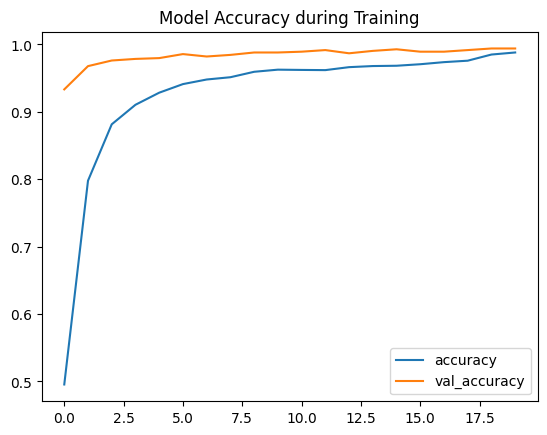

In [87]:
losses[['accuracy','val_accuracy']].plot()
plt.title('Model Accuracy during Training')

Text(0.5, 1.0, 'Model Loss during Training')

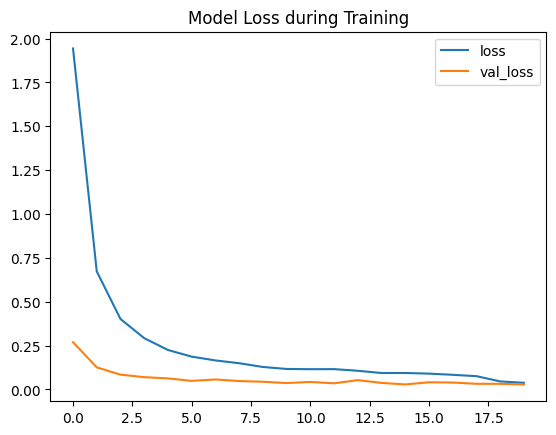

In [88]:
losses[['loss','val_loss']].plot()
plt.title('Model Loss during Training')

In [89]:
val_loss, val_accuracy=model.evaluate(val_data.dataset)
print(f"Validation Loss: {val_loss:.4f}")
print(f"Validation Accuracy: {val_accuracy:.4f}")

27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 74ms/step - accuracy: 0.9917 - loss: 0.0211
Validation Loss: 0.0271
Validation Accuracy: 0.9940


In [90]:
test_data = TFDataset(
    test_df,
    augment=False,
    batch_size=BATCH_SIZE,
    shuffle=False,
    image_size=image_size,
)

In [91]:
print("Number of samples:", len(test_data.df))
print("Number of batches:", len(test_data))

Number of samples: 360
Number of batches: 12


#### Classification Report

In [92]:
y_true = np.concatenate([y for x, y in val_data.dataset], axis=0)
y_pred = np.argmax(model.predict(val_data.dataset), axis=1)

print(classification_report(y_true, y_pred))

27/27 ━━━━━━━━━━━━━━━━━━━━ 9s 201ms/step
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00         4
         1.0       1.00      1.00      1.00        13
         2.0       1.00      1.00      1.00        61
         3.0       1.00      1.00      1.00         7
         4.0       1.00      1.00      1.00         6
         5.0       1.00      1.00      1.00        24
         6.0       1.00      1.00      1.00         4
         7.0       1.00      1.00      1.00        15
         8.0       1.00      1.00      1.00         4
         9.0       1.00      1.00      1.00         8
        10.0       1.00      1.00      1.00        11
        11.0       1.00      0.89      0.94         9
        12.0       1.00      1.00      1.00        35
        13.0       1.00      1.00      1.00         3
        14.0       1.00      1.00      1.00        62
        15.0       0.75      0.75      0.75         4
        16.0       0.89      1.00      0

In [93]:
y_true = np.concatenate([y for x, y in test_data.dataset], axis=0)
y_pred = np.argmax(model.predict(test_data.dataset), axis=1)

print(classification_report(y_true, y_pred))

12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 76ms/step
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00         2
         1.0       1.00      1.00      1.00         5
         2.0       1.00      1.00      1.00        26
         3.0       1.00      1.00      1.00         3
         4.0       1.00      1.00      1.00         3
         5.0       1.00      1.00      1.00        10
         6.0       1.00      1.00      1.00         1
         7.0       1.00      1.00      1.00         7
         8.0       1.00      1.00      1.00         1
         9.0       1.00      1.00      1.00         4
        10.0       1.00      1.00      1.00         5
        11.0       1.00      1.00      1.00         4
        12.0       1.00      1.00      1.00        15
        13.0       1.00      1.00      1.00         1
        14.0       1.00      1.00      1.00        26
        15.0       1.00      1.00      1.00         1
        16.0       1.00      1.00      1.

In [94]:
report = classification_report(y_true, y_pred, output_dict=True)
df_report = pd.DataFrame(report).transpose()
df_report

,precision,recall,f1-score,support
0.0,1.0,1.0,1.0,2.0
1.0,1.0,1.0,1.0,5.0
2.0,1.0,1.0,1.0,26.0
3.0,1.0,1.0,1.0,3.0
4.0,1.0,1.0,1.0,3.0
5.0,1.0,1.0,1.0,10.0
6.0,1.0,1.0,1.0,1.0
7.0,1.0,1.0,1.0,7.0
8.0,1.0,1.0,1.0,1.0
9.0,1.0,1.0,1.0,4.0


In [95]:
print("Overall precision:", report["weighted avg"]["precision"])
print("Overall recall:", report["weighted avg"]["recall"])
print("Overall f1-score:", report["weighted avg"]["f1-score"])
print("Overall accuracy:",report["accuracy"])

Overall precision: 1.0
Overall recall: 1.0
Overall f1-score: 1.0
Overall accuracy: 1.0


### Test Inference

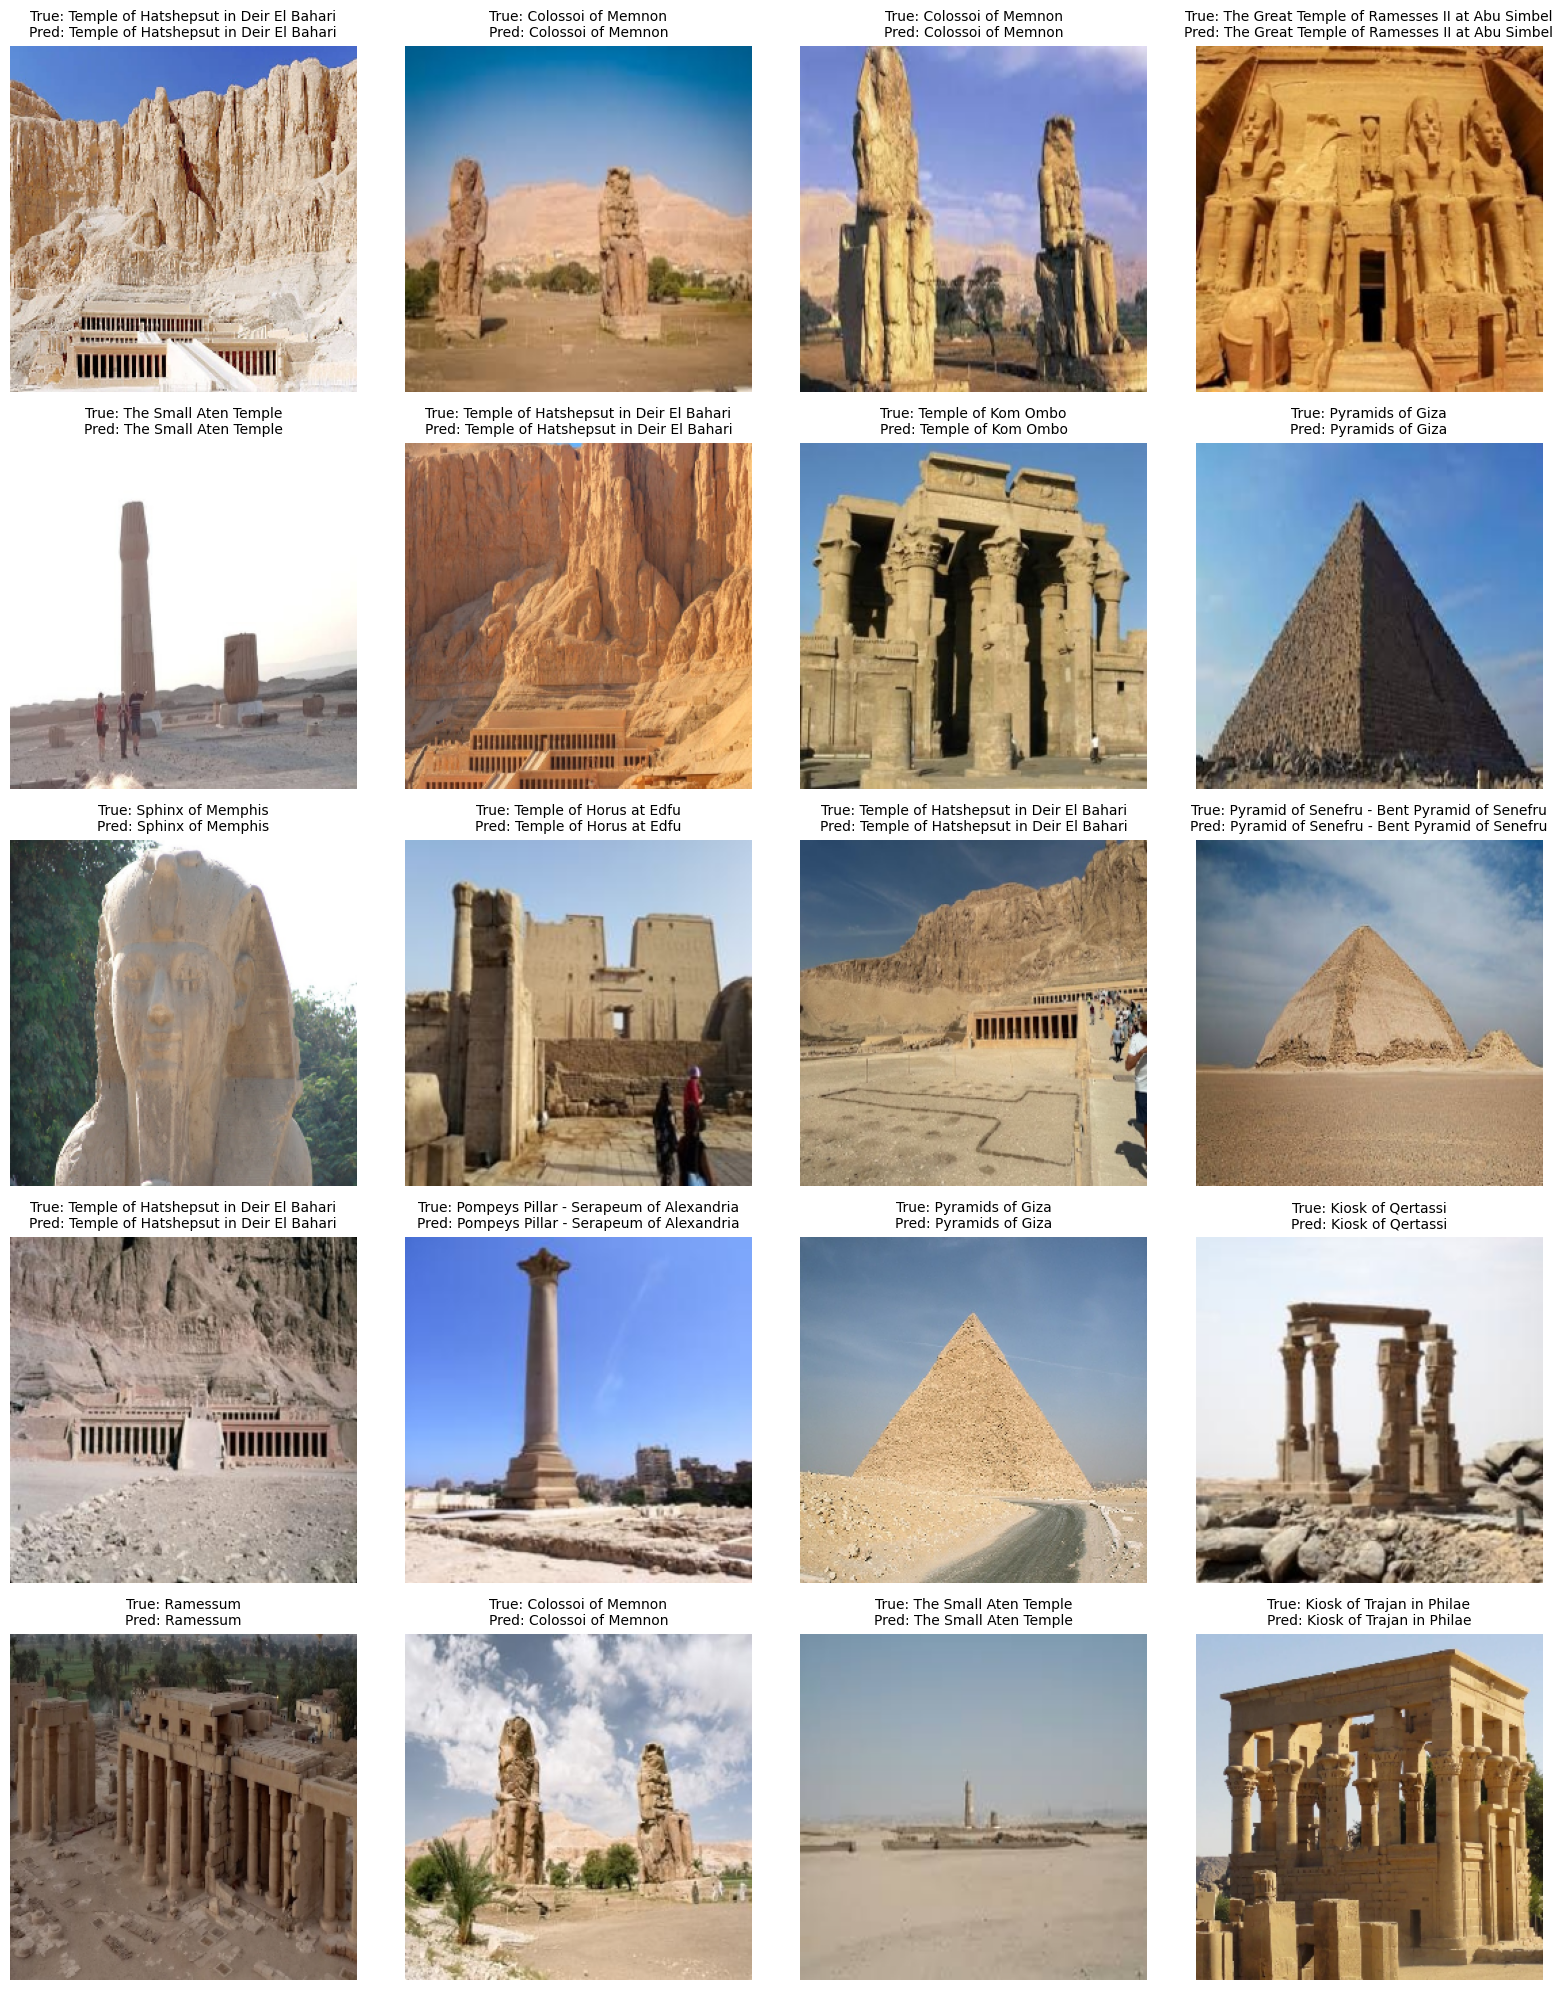

In [ ]:
def display_original_samples(df, model, encoder, image_size=256, n=12):
    samples = df.sample(n)

    cols = 4
    rows = math.ceil(n / cols)

    plt.figure(figsize=(4 * cols, 4 * rows))

    for i, (_, row) in enumerate(samples.iterrows()):
        path = row["path"]
        true_id = int(row["label"])

        # Load original image
        img_bgr = cv2.imread(path)
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        img_resized = cv2.resize(img_rgb, (image_size, image_size))

        # Prepare for model 
        x = img_resized.astype(np.float32)
        x = preprocess_input(x)
        x = np.expand_dims(x, axis=0)

        # Predict
        pred = model.predict(x, verbose=0)
        pred_id = np.argmax(pred)

        true_label = encoder.inverse_transform([true_id])[0]
        pred_label = encoder.inverse_transform([pred_id])[0]
        
        plt.subplot(rows, cols, i + 1)
        plt.imshow(img_resized)
        plt.title(f"True: {true_label}\nPred: {pred_label}", fontsize=10)
        plt.axis("off")

    plt.tight_layout()
    plt.show()

display_original_samples(test_df, model, encoder, image_size=256, n=20)



### Save Outputs

In [104]:
import pickle
model.save('/kaggle/working/resnet50.keras')

encoder_file = "label_encoder.pkl"

with open(encoder_file, "wb") as f:
    pickle.dump(encoder, f)